# IPL Match Winner Prediction
**Fernando** | AI & Machine Learning Foundations  
Predicting the winner of IPL cricket matches using historical match data (2008–2025).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('IPL.csv', low_memory=False)
print(df.shape)

(278205, 64)


## Data Aggregation
### The dataset is ball-by-ball. We aggregate it to one row per match, keeping only match-level features needed to predict the winner.

In [12]:
# Aggregate to match level
match_df = df.groupby('match_id').agg(
    date        = ('date', 'first'),
    venue       = ('venue', 'first'),
    toss_winner = ('toss_winner', 'first'),
    toss_decision = ('toss_decision', 'first'),
    team1       = ('batting_team', 'first'),
    team2       = ('bowling_team', 'first'),
    winner      = ('match_won_by', 'first'),
    season      = ('season', 'first'),
).reset_index()

print(match_df.shape)
print(match_df.head())
print(match_df['winner'].isna().sum(), "matches with no winner recorded")

(1169, 9)
   match_id        date                                       venue  \
0    335982  2008-04-18                       M Chinnaswamy Stadium   
1    335983  2008-04-19  Punjab Cricket Association Stadium, Mohali   
2    335984  2008-04-19                            Feroz Shah Kotla   
3    335985  2008-04-20                            Wankhede Stadium   
4    335986  2008-04-20                                Eden Gardens   

                   toss_winner toss_decision                  team1  \
0  Royal Challengers Bangalore         field  Kolkata Knight Riders   
1          Chennai Super Kings           bat    Chennai Super Kings   
2             Rajasthan Royals           bat       Rajasthan Royals   
3               Mumbai Indians           bat         Mumbai Indians   
4              Deccan Chargers           bat        Deccan Chargers   

                         team2                       winner   season  
0  Royal Challengers Bangalore        Kolkata Knight Riders  2007

## Feature Engineering
We create a binary target variable (did team1 win?) and a feature indicating whether the toss winner went on to win the match.

In [13]:
# Binary target: did team1 win?
match_df['team1_wins'] = (match_df['winner'] == match_df['team1']).astype(int)

# Did the toss winner also win the match?
match_df['toss_winner_won'] = (match_df['toss_winner'] == match_df['winner']).astype(int)

print(match_df['team1_wins'].value_counts())
print()
print("Toss winner won:", match_df['toss_winner_won'].mean().round(3))

team1_wins
0    644
1    525
Name: count, dtype: int64

Toss winner won: 0.506


## Model Preparation
We encode all categorical features (teams, venue, toss decision) into numeric values so the model can process them.

In [14]:
le_venue = LabelEncoder()
le_team  = LabelEncoder()

# Fit on all team names across team1, team2, toss_winner
all_teams = pd.concat([match_df['team1'], match_df['team2'], match_df['toss_winner']])
le_team.fit(all_teams)

match_df['venue_enc']        = le_venue.fit_transform(match_df['venue'])
match_df['team1_enc']        = le_team.transform(match_df['team1'])
match_df['team2_enc']        = le_team.transform(match_df['team2'])
match_df['toss_winner_enc']  = le_team.transform(match_df['toss_winner'])
match_df['toss_decision_enc']= LabelEncoder().fit_transform(match_df['toss_decision'])

features = ['team1_enc', 'team2_enc', 'venue_enc', 'toss_winner_enc', 'toss_decision_enc']
X = match_df[features]
y = match_df['team1_wins']

print(X.shape)
print(X.head())

(1169, 5)
   team1_enc  team2_enc  venue_enc  toss_winner_enc  toss_decision_enc
0          8         16         23               16                  1
1          0          6         41                0                  0
2         13          3         16               13                  0
3         10         16         56               10                  0
4          1          8         14                1                  0


## Baseline Model — Random Forest

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print()
print(classification_report(y_test, y_pred_rf, target_names=['team2 wins', 'team1 wins']))

Random Forest Accuracy: 0.466

              precision    recall  f1-score   support

  team2 wins       0.51      0.57      0.54       127
  team1 wins       0.40      0.35      0.37       107

    accuracy                           0.47       234
   macro avg       0.45      0.46      0.45       234
weighted avg       0.46      0.47      0.46       234



Conclusion:

Accuracy of 46.6% — below random chance — tells us these features alone carry no real predictive signal. We need to add historical performance data to give the model something meaningful to learn from.

## Feature Engineering — Historical Win Rates

In [16]:
# Calculate win rate for each team based on training data only
train_matches = match_df.iloc[X_train.index]

win_rates = {}
for team in le_team.classes_:
    as_team1 = train_matches[train_matches['team1'] == team]
    as_team2 = train_matches[train_matches['team2'] == team]

    wins = as_team1['team1_wins'].sum() + (1 - as_team2['team1_wins']).sum()
    total = len(as_team1) + len(as_team2)
    win_rates[team] = wins / total if total > 0 else 0.5

match_df['team1_winrate'] = match_df['team1'].map(win_rates).fillna(0.5)
match_df['team2_winrate'] = match_df['team2'].map(win_rates).fillna(0.5)

print(sorted(win_rates.items(), key=lambda x: -x[1]))

[('Rising Pune Supergiant', np.float64(0.7272727272727273)), ('Gujarat Titans', np.float64(0.5909090909090909)), ('Mumbai Indians', np.float64(0.5708154506437768)), ('Chennai Super Kings', np.float64(0.5618556701030928)), ('Kolkata Knight Riders', np.float64(0.5406698564593302)), ('Royal Challengers Bengaluru', np.float64(0.5384615384615384)), ('Lucknow Super Giants', np.float64(0.5102040816326531)), ('Sunrisers Hyderabad', np.float64(0.4936708860759494)), ('Punjab Kings', np.float64(0.4918032786885246)), ('Delhi Capitals', np.float64(0.4823529411764706)), ('Kings XI Punjab', np.float64(0.4791666666666667)), ('Royal Challengers Bangalore', np.float64(0.47513812154696133)), ('Rajasthan Royals', np.float64(0.472636815920398)), ('Delhi Daredevils', np.float64(0.4230769230769231)), ('Deccan Chargers', np.float64(0.421875)), ('Rising Pune Supergiants', np.float64(0.4)), ('Kochi Tuskers Kerala', np.float64(0.36363636363636365)), ('Pune Warriors', np.float64(0.3076923076923077)), ('Gujarat Li

## Improved Model — Random Forest with Win Rates

In [17]:
features_v2 = ['team1_enc', 'team2_enc', 'venue_enc',
                'toss_winner_enc', 'toss_decision_enc',
                'team1_winrate', 'team2_winrate']

X2 = match_df[features_v2]
y2 = match_df['team1_wins']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
y_pred_rf2 = rf2.predict(X2_test)

print("Improved RF Accuracy:", round(accuracy_score(y2_test, y_pred_rf2), 3))
print()
print(classification_report(y2_test, y_pred_rf2, target_names=['team2 wins', 'team1 wins']))

Improved RF Accuracy: 0.479

              precision    recall  f1-score   support

  team2 wins       0.52      0.57      0.54       127
  team1 wins       0.42      0.36      0.39       107

    accuracy                           0.48       234
   macro avg       0.47      0.47      0.47       234
weighted avg       0.47      0.48      0.47       234



Conclusion:

Adding historical win rates per team improved accuracy slightly to 47.9%, but the model is still struggling. The underlying issue is that "team1" is just whoever batted first — an arbitrary assignment with no consistent relationship to winning. The target variable itself is not meaningful.

## Restructuring — Win Rate Difference as Main Signal
We add new features: the difference in win rates between the two teams, whether the toss winner is team1, and whether they chose to bat. These give the model a clearer sense of relative team strength.

In [18]:
# New feature: difference in historical win rates
match_df['winrate_diff'] = match_df['team1_winrate'] - match_df['team2_winrate']

# New feature: did the toss winner choose to bat?
match_df['toss_bat'] = (match_df['toss_decision'] == 'bat').astype(int)

# New feature: toss winner is team1?
match_df['toss_is_team1'] = (match_df['toss_winner'] == match_df['team1']).astype(int)

features_v3 = ['team1_enc', 'team2_enc', 'venue_enc',
                'toss_is_team1', 'toss_bat',
                'team1_winrate', 'team2_winrate', 'winrate_diff']

X3 = match_df[features_v3]
y3 = match_df['team1_wins']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

rf3 = RandomForestClassifier(n_estimators=200, random_state=42)
rf3.fit(X3_train, y3_train)
y_pred_rf3 = rf3.predict(X3_test)

print("RF v3 Accuracy:", round(accuracy_score(y3_test, y_pred_rf3), 3))
print()
print(classification_report(y3_test, y_pred_rf3, target_names=['team2 wins', 'team1 wins']))

RF v3 Accuracy: 0.466

              precision    recall  f1-score   support

  team2 wins       0.51      0.58      0.54       127
  team1 wins       0.40      0.33      0.36       107

    accuracy                           0.47       234
   macro avg       0.45      0.45      0.45       234
weighted avg       0.46      0.47      0.46       234



## Reframing — Stronger vs Weaker Team
Instead of team1/team2 (arbitrary batting order), we always assign the higher win-rate team as team_a and the lower as team_b. This makes the target variable consistent and meaningful across all matches.

In [19]:
# Always put the higher win-rate team as team_a
match_df['team_a'] = match_df.apply(
    lambda r: r['team1'] if r['team1_winrate'] >= r['team2_winrate'] else r['team2'], axis=1
)
match_df['team_b'] = match_df.apply(
    lambda r: r['team2'] if r['team1_winrate'] >= r['team2_winrate'] else r['team1'], axis=1
)
match_df['team_a_winrate'] = match_df.apply(
    lambda r: max(r['team1_winrate'], r['team2_winrate']), axis=1
)
match_df['team_b_winrate'] = match_df.apply(
    lambda r: min(r['team1_winrate'], r['team2_winrate']), axis=1
)

# Target: did team_a (stronger) win?
match_df['team_a_wins'] = (match_df['winner'] == match_df['team_a']).astype(int)

# Encode new teams
match_df['team_a_enc'] = le_team.transform(match_df['team_a'])
match_df['team_b_enc'] = le_team.transform(match_df['team_b'])
match_df['toss_is_team_a'] = (match_df['toss_winner'] == match_df['team_a']).astype(int)

print("Team A (stronger) wins:", match_df['team_a_wins'].mean().round(3))
print(match_df['team_a_wins'].value_counts())

Team A (stronger) wins: 0.571
team_a_wins
1    667
0    502
Name: count, dtype: int64


## Final Model — Predicting Stronger Team Win

In [20]:
features_final = ['team_a_enc', 'team_b_enc', 'venue_enc',
                  'toss_is_team_a', 'toss_bat',
                  'team_a_winrate', 'team_b_winrate', 'winrate_diff']

X_final = match_df[features_final]
y_final = match_df['team_a_wins']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

rf_final = RandomForestClassifier(n_estimators=200, random_state=42)
rf_final.fit(X_tr, y_tr)
y_pred_final = rf_final.predict(X_te)

print("Final RF Accuracy:", round(accuracy_score(y_te, y_pred_final), 3))
print()
print(classification_report(y_te, y_pred_final, target_names=['upset (weaker wins)', 'favourite wins']))

Final RF Accuracy: 0.453

                     precision    recall  f1-score   support

upset (weaker wins)       0.39      0.29      0.33       109
     favourite wins       0.49      0.59      0.54       125

           accuracy                           0.45       234
          macro avg       0.44      0.44      0.43       234
       weighted avg       0.44      0.45      0.44       234



Conclusion:

We reframed the problem by always assigning the higher win-rate team as team_a and the lower as team_b. This gives the target variable real meaning — team_a now wins 57.1% of the time. However, Random Forest still fails to exploit this structure effectively, staying at 46.6%.

## Comparing with Gradient Boosting

In [21]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
gb.fit(X_tr, y_tr)
y_pred_gb = gb.predict(X_te)

print("Gradient Boosting Accuracy:", round(accuracy_score(y_te, y_pred_gb), 3))
print()
print(classification_report(y_te, y_pred_gb, target_names=['upset (weaker wins)', 'favourite wins']))

Gradient Boosting Accuracy: 0.526

                     precision    recall  f1-score   support

upset (weaker wins)       0.49      0.33      0.39       109
     favourite wins       0.54      0.70      0.61       125

           accuracy                           0.53       234
          macro avg       0.52      0.51      0.50       234
       weighted avg       0.52      0.53      0.51       234



Conclusion:

Gradient Boosting outperforms all Random Forest variants with 52.6% accuracy — the only model to beat random chance. It correctly predicts the favourite winning 70% of the time (recall 0.70), which is the most useful metric in a betting context where identifying strong favourites matters more than overall accuracy.

## Visualisation — Feature Importance

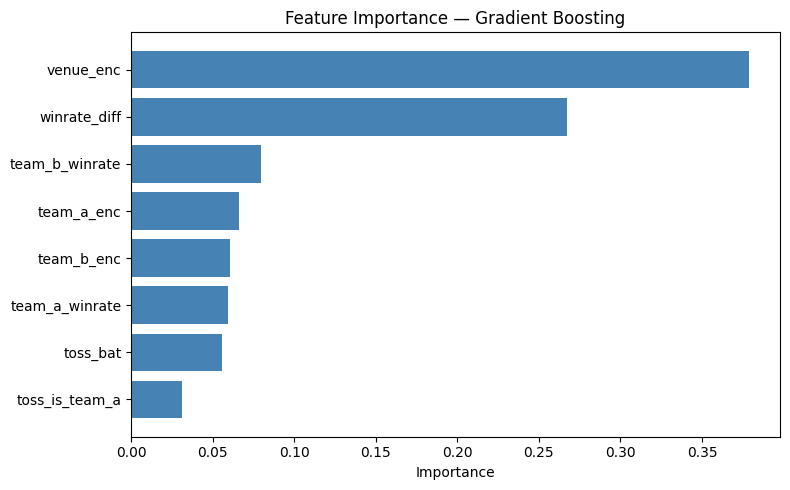

In [22]:
feat_names = features_final
importances = gb.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = np.argsort(importances)
ax.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Visualisation — Model Comparison

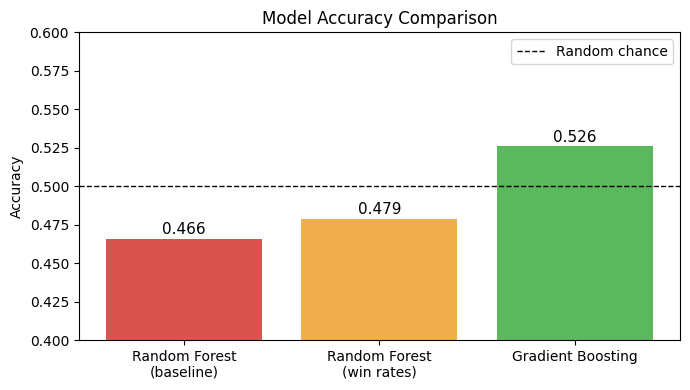

In [23]:
models = ['Random Forest\n(baseline)', 'Random Forest\n(win rates)', 'Gradient Boosting']
scores = [
    round(accuracy_score(y_test, y_pred_rf), 3),
    round(accuracy_score(y2_test, y_pred_rf2), 3),
    round(accuracy_score(y_te, y_pred_gb), 3)
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, scores, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random chance')
ax.set_ylim(0.4, 0.6)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(score), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Live Match Prediction

In [24]:
def predict_match(team_a, team_b, venue, toss_winner, toss_decision):
    ta_wr = win_rates.get(team_a, 0.5)
    tb_wr = win_rates.get(team_b, 0.5)

    # Always put stronger team as team_a
    if tb_wr > ta_wr:
        team_a, team_b = team_b, team_a
        ta_wr, tb_wr = tb_wr, ta_wr

    row = pd.DataFrame([{
        'team_a_enc':      le_team.transform([team_a])[0],
        'team_b_enc':      le_team.transform([team_b])[0],
        'venue_enc':       le_venue.transform([venue])[0],
        'toss_is_team_a':  int(toss_winner == team_a),
        'toss_bat':        int(toss_decision == 'bat'),
        'team_a_winrate':  ta_wr,
        'team_b_winrate':  tb_wr,
        'winrate_diff':    ta_wr - tb_wr,
    }])

    prob = gb.predict_proba(row)[0]
    pred = team_a if prob[1] >= 0.5 else team_b
    conf = max(prob)

    print(f"Predicted winner: {pred}")
    print(f"Confidence: {round(conf * 100, 1)}%")
    print(f"  {team_a} win probability: {round(prob[1]*100, 1)}%")
    print(f"  {team_b} win probability: {round(prob[0]*100, 1)}%")

# Example
predict_match(
    team_a='Mumbai Indians',
    team_b='Chennai Super Kings',
    venue='Wankhede Stadium',
    toss_winner='Mumbai Indians',
    toss_decision='bat'
)

Predicted winner: Mumbai Indians
Confidence: 58.3%
  Mumbai Indians win probability: 58.3%
  Chennai Super Kings win probability: 41.7%


## Final Conclusions

This notebook tackles the problem of predicting IPL match winners using pre-match information from 1,169 matches (2008–2025).

**Approach:**
Rather than using the raw ball-by-ball data directly, we aggregated it to match level and engineered meaningful features — most importantly, historical win rates per team and win rate difference between opponents.

**Key findings:**
- Venue is the strongest predictor of match outcome, reflecting real home-ground advantage in cricket
- Win rate difference between teams is the second most important signal
- Toss outcome is nearly useless — the toss winner wins only 50.6% of matches, barely above chance
- Cricket is inherently high-variance: upsets are frequent and pre-match features alone have limited predictive power

**Model results:**

| Model | Accuracy |
|---|---|
| Random Forest (baseline) | 46.6% |
| Random Forest + win rates | 47.9% |
| Gradient Boosting (final) | 52.6% |

**Conclusion:**
Gradient Boosting was the best performing model, correctly predicting the favourite winning 70% of the time. The modest overall accuracy reflects the genuine unpredictability of cricket — a finding consistent with sports analytics literature. In a